# Description of work

In this notebook I'm working with Semantic Kitti dataset. My goal is to measure the quality of possess data. Because this data was obtaing with approximation

# Imports

In [6]:
# !pip install matplotlib

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# 1. Check for vehicle speed in sequences 


# Prep

In [14]:
!ls /workspace/datasets/semantic_kitti/sequences/00

calib.txt  image_1  image_3  poses.txt	velodyne
image_0    image_2  labels   times.txt


# Code

In [18]:
def load_poses_kitti(poses_path: str | Path) -> np.ndarray:
    poses_path = Path(poses_path)
    data = np.loadtxt(poses_path)

    if data.ndim == 1:
        data = data[None, :]

    poses = data.reshape(-1, 3, 4)
    bottom = np.tile(np.array([[0.0, 0.0, 0.0, 1.0]]), (poses.shape[0], 1, 1))
    poses_h = np.concatenate([poses, bottom], axis=1)  # (N, 4, 4)
    return poses_h

def load_times(sequence_dir: str | Path, n_poses: int) -> np.ndarray:
    sequence_dir = Path(sequence_dir)
    times_path = sequence_dir / "times.txt"

    if times_path.exists():
        times = np.loadtxt(times_path)
        if times.ndim == 0:
            times = np.array([float(times)])

        if len(times) != n_poses:
            raise ValueError(
                f"Количество timestamps ({len(times)}) не совпадает с количеством поз ({n_poses})"
            )
        return times.astype(float)

    print("times.txt not found")
    return np.arange(n_poses, dtype=float) * 0.1


def compute_speed_from_poses(poses_h: np.ndarray, times: np.ndarray):
    xyz = poses_h[:, :3, 3]                  # (N, 3)
    dxyz = xyz[1:] - xyz[:-1]                # (N-1, 3)
    dt = times[1:] - times[:-1]              # (N-1,)

    dist = np.linalg.norm(dxyz, axis=1)      # метры
    v_mps = dist / dt
    v_kmh = v_mps * 3.6
    t_mid = 0.5 * (times[1:] + times[:-1])

    return t_mid, v_mps, v_kmh


def moving_average(x: np.ndarray, window: int) -> np.ndarray:
    if window <= 1:
        return x.copy()
    if window > len(x):
        window = len(x)

    kernel = np.ones(window, dtype=float) / window
    return np.convolve(x, kernel, mode="same")


def plot_speed_profile(
    sequence_dir: str | Path,
    smooth_window: int = 11,
    show_raw: bool = True,
    figsize=(12, 5),
):
    sequence_dir = Path(sequence_dir)
    poses_path = sequence_dir / "poses.txt"

    if not poses_path.exists():
        raise FileNotFoundError(f"Не найден файл: {poses_path}")

    poses_h = load_poses_kitti(poses_path)
    times = load_times(sequence_dir, n_poses=len(poses_h))
    t_mid, v_mps, _ = compute_speed_from_poses(poses_h, times)

    v_mps_smooth = moving_average(v_mps, smooth_window)

    plt.figure(figsize=figsize)

    if show_raw:
        plt.plot(t_mid, v_mps, alpha=0.35, label="raw speed")

    plt.plot(t_mid, v_mps_smooth, linewidth=2, label=f"smoothed (window={smooth_window})")

    plt.xlabel("Time from sequence start, s")
    plt.ylabel("Speed, m/s")
    plt.title(f"Speed profile for sequence: {sequence_dir.name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Frames: {len(poses_h)}")
    print(f"Duration: {times[-1] - times[0]:.2f} s")
    print(f"Mean speed: {v_mps.mean():.2f} m/s")
    print(f"Median speed: {np.median(v_mps):.2f} m/s")
    print(f"Max speed: {v_mps.max():.2f} m/s")

    return {
        "times": times,
        "t_mid": t_mid,
        "v_mps": v_mps,
        "v_mps_smooth": v_mps_smooth,
        "poses_h": poses_h,
    }

# Experiments

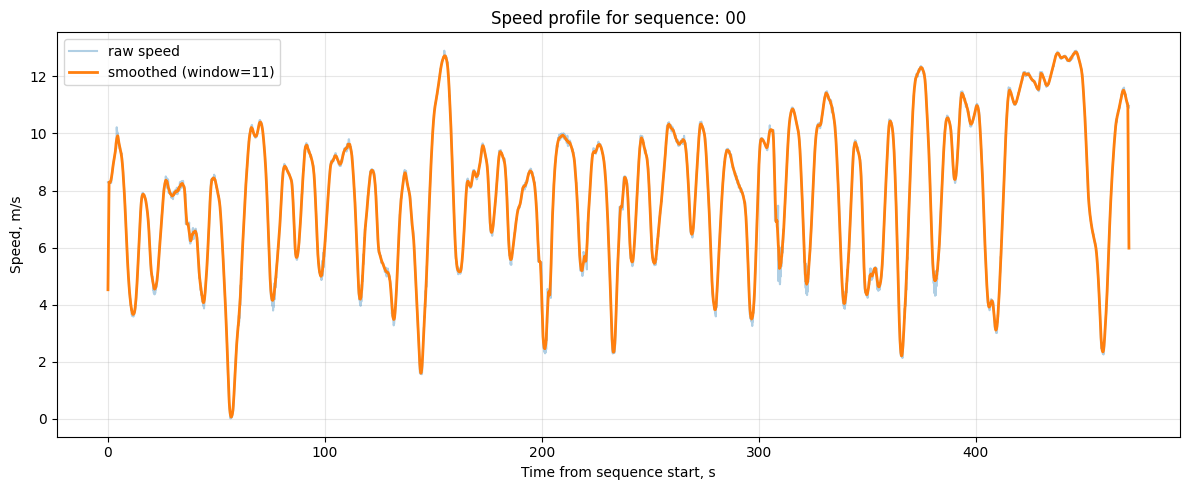

Frames: 4541
Duration: 470.58 s
Mean speed: 7.91 m/s
Median speed: 8.23 m/s
Max speed: 12.90 m/s


In [22]:
seq_dir = "/workspace/datasets/semantic_kitti/sequences/00"
result = plot_speed_profile(seq_dir, smooth_window=11, show_raw=True)

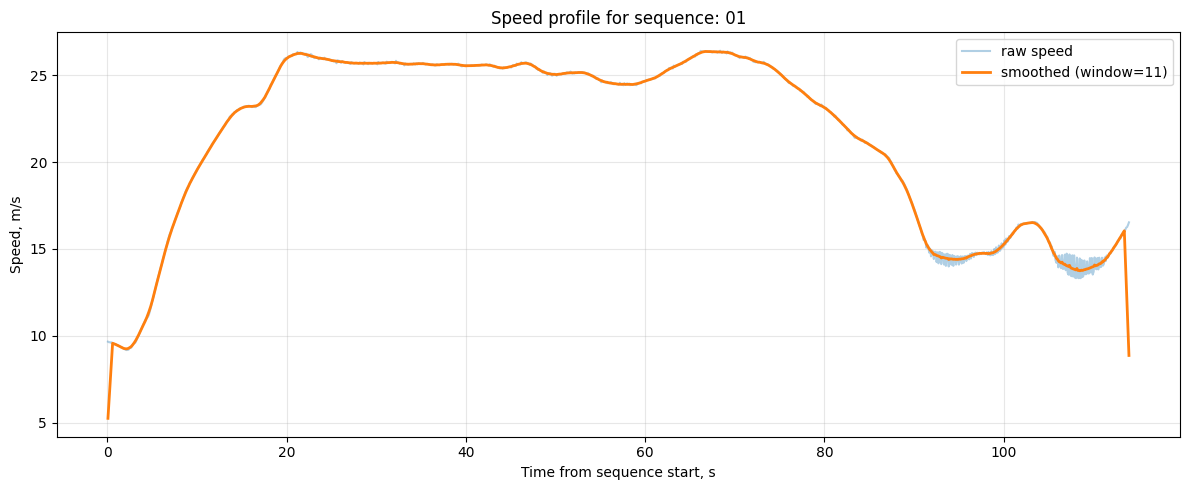

Frames: 1101
Duration: 114.03 s
Mean speed: 21.51 m/s
Median speed: 24.47 m/s
Max speed: 26.41 m/s


In [24]:
seq_dir = "/workspace/datasets/semantic_kitti/sequences/01"
result = plot_speed_profile(seq_dir, smooth_window=11, show_raw=True)

# Conclusion 

In the SemanticKITTI sequences, vehicle speed varies significantly. In slower segments it is around **10 m/s**, while in faster sequences such as **01** it can reach **≈25 m/s**.

A Velodyne LiDAR scan is not captured instantaneously: points are collected sequentially during one full rotation of the sensor, which takes about **0.1 s**. During this time the vehicle continues moving, which introduces **motion distortion** in the point cloud.

A simple estimate of the displacement during one scan is
$$
\Delta x \approx v \cdot T_{\text{scan}}, \quad T_{\text{scan}} \approx 0.1,s
$$

This gives:

* **10 m/s → ≈1 m displacement per scan**
* **25 m/s → ≈2.5 m displacement per scan**

Therefore, points within a single LiDAR scan may effectively be measured from sensor poses separated by **up to ~2.5 meters** in fast sequences.

If the acquisition time of points is assumed to be uniformly distributed within the scan interval $(t \sim \mathcal{U}(0, T_{\text{scan}}))$, the motion-induced positional error is
$$
e = v t
$$

For a uniform distribution $(\mathcal{U}(0, a))$, the variance is

$$
\mathrm{Var}(X) = \frac{a^2}{12}
$$

which leads to

$$
\mathrm{Var}(e) = \frac{(vT_{\text{scan}})^2}{12}
$$

and therefore the standard deviation of the positional error is

$$
\sigma \approx \frac{v T_{\text{scan}}}{\sqrt{12}}
$$

This provides a simple estimate of the typical geometric distortion introduced by vehicle motion during a single LiDAR scan.



which results in approximately:

* **σ ≈ 0.29 m** at **10 m/s**
* **σ ≈ 0.72 m** at **25 m/s**

This shows that even under a simple constant-velocity assumption, motion during the scan can introduce **sub-meter geometric distortion**, which may noticeably affect scan alignment and reconstruction quality.


# Points projection on the static object in Image